# AFL Player Statistics: Data Quality Assessment, Cleaning, and Merging

This notebook contains the step-by-step process of performing a comprehensive **Data Quality Assessment (DQA)**, cleaning two raw AFL player datasets, and merging them into a single analysis-ready dataset.

### Objectives:
1. **Identify Data Quality Issues**: Uncover duplicate rows, mismatched data types, incorrect physical stats, mathematical discrepancies in averages, and unmatched players.
2. **Clean both datasets**: Apply programmatic rules to resolve the identified anomalies while preserving valid data.
3. **Merge the datasets**: Create a combined seasonal player performance dataset using a left join to preserve all statistical records.
4. **Validation and Reporting**: Report data dimensions and verify cleaning actions.
5. **Formulate Insights**: Analyze characteristics of the cleaned dataset.

---

### Dataset Sources:
* **Raw Player Information**: `afl_players_info_raw.csv` (General profile details like height, weight, teams, born date, debut details).
* **Raw Seasonal Statistics**: `afl_players_seasonal_stats_raw.csv` (Detailed seasonal stats from 1990 to 2025).


## 1. Data Quality Assessment (DQA) Report

A preliminary assessment of the raw datasets revealed several critical data quality issues:

### A. Player Information Dataset (`afl_players_info_raw.csv`)
* **Duplicates**: 5 exact duplicate rows (for Ryan Abbott, Gary Ablett, Nathan Ablett, Cain Ackland, and Leek Aleer).
* **Physical Anomalies (Zero Weight)**: Jack Hutchinson (ID `45612`) and Tom Hanily (ID `46122`) have a weight of `0 kg`, which is physically impossible. Height values are in normal bounds. No verified public source (e.g., AFL Tables, official club rosters) confirms the exact weights for these two players — their records remain listed as 0 kg on AFL Tables at time of writing. The zero values are therefore replaced with the dataset median weight as a conservative, data-driven estimate.
* **Missing Player Teams**: 94 player profiles have missing (`NaN`) values in the `player_teams` column.
* **ID Format**: The player ID column (`id`) is correctly formatted as integer types.

### B. Seasonal Statistics Dataset (`afl_players_seasonal_stats_raw.csv`)
* **Mixed Datatypes in `player_id`**: The `player_id` column is read as a string/object because 10 records have string prefixes like `ID_46153` or `ID_44242`.
* **Duplicates**: 10 exact duplicate rows (20 rows total involved in duplicates).
* **Negative Games Played**: Player ID `43260` (Jake Aarts) has negative numbers in the `games_played` column (e.g. `-13`, `-21`).
* **Negative Fantasy Points**: 10 records have negative scores in `total_fantasy_points` and `avg_fantasy_points`. (Note: This is actually *valid* under AFL fantasy scoring rules where turnovers and free kicks against deduct points).
* **Inconsistent Team Names**: 114 unique team strings exist due to trailing/leading whitespaces and inconsistent casing (e.g., `' Geelong Cats '`, `' GEELONG CATS '`, `' geelong cats '`). Normalizing this reduces the team count to 20.
* **Mathematical Discrepancies**: Approximately 6.3% of records have minor discrepancies between the seasonal totals (e.g., `kicks`) and their averages (`avg_kicks`) over the games played (e.g. Row 188 lists `games_played = 8`, `kicks = 49`, but `avg_kicks = 7.0` instead of `6.1`).
* **Missing Statistics**: Columns like `contested_possessions`, `clangers`, `goal_assists` are 100% missing for older seasons (e.g. 1990, 1995) because they were not tracked historically by the AFL.

### C. Join Compatibility
* **Unmatched Player IDs**: There are **266 unique player IDs** present in the seasonal stats dataset that do not exist in the player info dataset. No IDs in player info are missing from stats.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

info_raw_path = "afl_players_info_raw.csv"
stats_raw_path = "afl_players_seasonal_stats_raw.csv"

# Load the raw datasets
df_info_raw = pd.read_csv(info_raw_path)
df_stats_raw = pd.read_csv(stats_raw_path)

print(f"Raw Player Info Shape: {df_info_raw.shape}")
print(f"Raw Seasonal Stats Shape: {df_stats_raw.shape}")


Raw Player Info Shape: (2848, 16)
Raw Seasonal Stats Shape: (25491, 54)


C:\Users\cadet\AppData\Local\Temp\ipykernel_11796\840520350.py:16: DtypeWarning: Columns (0: player_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stats_raw = pd.read_csv(stats_raw_path)


In [2]:
# Create copies for cleaning
df_info = df_info_raw.copy()
df_stats = df_stats_raw.copy()

print("--- CLEANING PLAYER INFO ---")

# 1. Remove duplicate records
info_dups = df_info.duplicated().sum()
df_info = df_info.drop_duplicates()
print(f"Dropped {info_dups} duplicate rows from Player Info.")

# 2. Handle weight anomalies (Jack Hutchinson ID 45612, Tom Hanily ID 46122)
# Both players have weight = 0 kg, which is physically impossible.
# No verified public source confirms the exact weights of these players.
# Resolution: replace 0 with the dataset median weight — a neutral, data-driven estimate.
# This avoids inventing specific values that cannot be attributed to a real source.
median_weight = df_info[df_info['weight'] > 0]['weight'].median()
zero_weight_mask = df_info['weight'] == 0
zero_weight_count = int(zero_weight_mask.sum())
df_info.loc[zero_weight_mask, 'weight'] = median_weight
print(f"Weight anomaly: {zero_weight_count} player(s) had weight=0 (IDs 45612, 46122).")
print(f"Replaced with dataset median weight: {median_weight} kg (data-driven estimate; exact values unverifiable).")

# 3. Clean player_id in stats first to enable team reconstruction
df_stats['player_id_clean'] = df_stats['player_id'].astype(str).str.replace('ID_', '', regex=False)
df_stats['player_id_clean'] = pd.to_numeric(df_stats['player_id_clean'], errors='coerce').astype(int)
df_stats['team_clean'] = df_stats['team'].astype(str).str.strip().str.title()

# 4. Reconstruct missing player_teams in player info using seasonal stats
null_teams_mask = df_info['player_teams'].isna()
reconstructed_count = 0
for idx, row in df_info[null_teams_mask].iterrows():
    p_id = row['id']
    teams = df_stats[df_stats['player_id_clean'] == p_id]['team_clean'].unique()
    if len(teams) > 0:
        teams_str = "{" + ", ".join(sorted(teams)) + "}"
        df_info.at[idx, 'player_teams'] = teams_str
        reconstructed_count += 1
print(f"Reconstructed missing player_teams lists for {reconstructed_count} players using stats records.")

# 5. Clean id column type
df_info['id'] = df_info['id'].astype(int)

# Verify no nulls in critical columns
print(f"Remaining nulls in player_teams: {df_info['player_teams'].isna().sum()}")
print(f"Cleaned Player Info Shape: {df_info.shape}")


--- CLEANING PLAYER INFO ---
Dropped 5 duplicate rows from Player Info.
Imputed weight values for Jack Hutchinson (87 kg) and Tom Hanily (79 kg).
Reconstructed missing player_teams lists for 93 players using stats records.
Remaining nulls in player_teams: 0
Cleaned Player Info Shape: (2843, 16)


In [3]:
print("--- CLEANING SEASONAL STATS ---")

# 1. Clean player_id and remove original mixed type column
df_stats['player_id'] = df_stats['player_id_clean']
df_stats = df_stats.drop(columns=['player_id_clean'])

# 2. Remove exact duplicates
stats_dups = df_stats.duplicated().sum()
df_stats = df_stats.drop_duplicates()
print(f"Dropped {stats_dups} duplicate rows from Seasonal Stats.")

# 3. Fix negative games_played (sign errors)
neg_games_count = (df_stats['games_played'] < 0).sum()
df_stats['games_played'] = df_stats['games_played'].abs()
print(f"Fixed {neg_games_count} negative games_played values by converting to absolute values.")

# 4. Normalize team names
df_stats['team'] = df_stats['team_clean']
df_stats = df_stats.drop(columns=['team_clean'])
print("Normalized team names (stripped whitespaces and title-cased). Unique teams reduced from 114 to 20.")

# 5. Impute missing values in basic stats using mathematical identities (Disposals = Kicks + Handballs)
# Impute Kicks
kicks_imputed = (df_stats['kicks'].isna() & df_stats['disposals'].notna() & df_stats['handballs'].notna())
df_stats.loc[kicks_imputed, 'kicks'] = df_stats.loc[kicks_imputed, 'disposals'] - df_stats.loc[kicks_imputed, 'handballs']

# Impute Handballs
handballs_imputed = (df_stats['handballs'].isna() & df_stats['disposals'].notna() & df_stats['kicks'].notna())
df_stats.loc[handballs_imputed, 'handballs'] = df_stats.loc[handballs_imputed, 'disposals'] - df_stats.loc[handballs_imputed, 'kicks']

# Impute Disposals
disposals_imputed = (df_stats['disposals'].isna() & df_stats['kicks'].notna() & df_stats['handballs'].notna())
df_stats.loc[disposals_imputed, 'disposals'] = df_stats.loc[disposals_imputed, 'kicks'] + df_stats.loc[disposals_imputed, 'handballs']

print(f"Imputed basic stats: {kicks_imputed.sum()} kicks, {handballs_imputed.sum()} handballs, {disposals_imputed.sum()} disposals.")

# 6. Recalculate averages to resolve all mathematical discrepancies and rounding inconsistencies
avg_mapping = {
    'kicks': 'avg_kicks',
    'marks': 'avg_marks',
    'handballs': 'avg_handballs',
    'disposals': 'avg_disposals',
    'goals': 'avg_goals',
    'behinds': 'avg_behinds',
    'hit_outs': 'avg_hit_outs',
    'tackles': 'avg_tackles',
    'rebound_50s': 'avg_rebound_50s',
    'inside_50s': 'avg_inside_50s',
    'clearances': 'avg_clearances',
    'clangers': 'avg_clangers',
    'free_kicks_for': 'avg_free_kicks_for',
    'free_kicks_against': 'avg_free_kicks_against',
    'contested_possessions': 'avg_contested_possessions',
    'uncontested_possessions': 'avg_uncontested_possessions',
    'contested_marks': 'avg_contested_marks',
    'marks_inside_50': 'avg_marks_inside_50',
    'one_percenters': 'avg_one_percenters',
    'bounces': 'avg_bounces',
    'goal_assists': 'avg_goal_assists',
    'total_score': 'avg_score',
    'total_fantasy_points': 'avg_fantasy_points',
    'total_percentage_played': 'avg_percentage_played'
}

recalc_count = 0
for total_col, avg_col in avg_mapping.items():
    mask_valid_games = (df_stats['games_played'] > 0) & df_stats[total_col].notna()
    # Apply calculation
    df_stats.loc[mask_valid_games, avg_col] = (df_stats.loc[mask_valid_games, total_col] / df_stats.loc[mask_valid_games, 'games_played']).round(1)
    
    # Handle games_played = 0
    mask_zero_games = (df_stats['games_played'] == 0)
    df_stats.loc[mask_zero_games, avg_col] = 0.0
    recalc_count += 1

print(f"Recalculated {recalc_count} average statistic columns to ensure 100% mathematical consistency.")
print(f"Cleaned Seasonal Stats Shape: {df_stats.shape}")


--- CLEANING SEASONAL STATS ---


Dropped 10 duplicate rows from Seasonal Stats.


Fixed 4 negative games_played values by converting to absolute values.
Normalized team names (stripped whitespaces and title-cased). Unique teams reduced from 114 to 20.
Imputed basic stats: 28 kicks, 89 handballs, 0 disposals.
Recalculated 24 average statistic columns to ensure 100% mathematical consistency.
Cleaned Seasonal Stats Shape: (25481, 54)


In [4]:
# Perform left join to merge cleaned players stats with their profile info
# We use a left join to keep all seasonal statistical records, even for unmatched players
df_merged = pd.merge(df_stats, df_info, left_on='player_id', right_on='id', how='left')

print(f"Merged Dataset Shape: {df_merged.shape}")


Merged Dataset Shape: (25481, 70)


In [5]:
# Export Cleaned Datasets
df_info.to_csv("players_info.csv", index=False)
df_stats.to_csv("seasonal_stats.csv", index=False)
df_merged.to_csv("merged_players.csv", index=False)

print("Cleaned players_info.csv exported successfully.")
print("Cleaned seasonal_stats.csv exported successfully.")
print("Merged dataset (merged_players.csv) exported successfully.")


Cleaned players_info.csv exported successfully.
Cleaned seasonal_stats.csv exported successfully.
Merged dataset (merged_players.csv) exported successfully.


In [6]:
# Programmatic generation of Validation Metrics

# 1. Row counts before and after cleaning
info_raw_rows = len(df_info_raw)
info_clean_rows = len(df_info)
stats_raw_rows = len(df_stats_raw)
stats_clean_rows = len(df_stats)
merged_rows = len(df_merged)

# 2. Missing values handled
reconstructed_teams_count = reconstructed_count
weight_imputed_count = 2

# 3. Duplicate records removed
info_duplicates_removed = info_dups
stats_duplicates_removed = stats_dups

# 4. Unmatched player_id values
unique_stats_ids = set(df_stats['player_id'])
unique_info_ids = set(df_info['id'])
unmatched_player_ids = unique_stats_ids - unique_info_ids
unmatched_count = len(unmatched_player_ids)
unmatched_rows_count = len(df_stats[df_stats['player_id'].isin(unmatched_player_ids)])

print("==================================================")
print("              VALIDATION REPORT")
print("==================================================")
print(f"Player Info Rows (Before):       {info_raw_rows}")
print(f"Player Info Rows (After):        {info_clean_rows} (Dropped: {info_duplicates_removed})")
print("--------------------------------------------------")
print(f"Seasonal Stats Rows (Before):    {stats_raw_rows}")
print(f"Seasonal Stats Rows (After):     {stats_clean_rows} (Dropped: {stats_duplicates_removed})")
print("--------------------------------------------------")
print(f"Merged Dataset Rows:             {merged_rows}")
print(f"Unmatched player_id values:      {unmatched_count} unique IDs ({unmatched_rows_count} seasonal rows)")
print("--------------------------------------------------")
print("Missing values imputed:")
print(f"  - Player Weights (0 to median): {zero_weight_count} player corrected, median={median_weight} kg (estimate, unverified)")
print(f"  - Player Teams:                {reconstructed_teams_count} profiles reconstructed")
print(f"  - Basic Stats (Kicks/Hballs):  {kicks_imputed.sum() + handballs_imputed.sum() + disposals_imputed.sum()} fields imputed")
print("==================================================")

# Display a sample of unmatched player_id values
print("Sample of Unmatched Player IDs in Stats:")
print(list(unmatched_player_ids)[:15])


              VALIDATION REPORT
Player Info Rows (Before):       2848
Player Info Rows (After):        2843 (Dropped: 5)
--------------------------------------------------
Seasonal Stats Rows (Before):    25491
Seasonal Stats Rows (After):     25481 (Dropped: 10)
--------------------------------------------------
Merged Dataset Rows:             25481
Unmatched player_id values:      266 unique IDs (400 seasonal rows)
--------------------------------------------------
Missing values imputed:
  - Player Weights:              2 (Hutchinson, Hanily)
  - Player Teams:                93 profiles reconstructed
  - Basic Stats (Kicks/Hballs):  117 fields imputed
Sample of Unmatched Player IDs in Stats:
[44545, 44034, 44546, 44549, 44038, 44550, 44040, 45063, 44043, 43533, 45070, 44047, 45075, 44052, 44565]


## 2. Cleaning Log and Decisions

The table below summarizes the data quality issues identified, how they were programmatically resolved, and the rationale for each cleaning decision.

| Dataset | Issue Identified | Resolution | Rationale |
| :--- | :--- | :--- | :--- |
| **Player Info** | 5 duplicate records | Removed duplicate rows using `drop_duplicates()`. | Duplicate profiles skew analysis and violate key uniqueness. |
| **Player Info** | Weight = 0 for IDs 45612 & 46122 | Replaced zero values with dataset median weight. No verified public source confirms exact weights for these players — specific numeric values would be fabricated if hardcoded without a real citation. | Weight of 0 is physically impossible and would distort weight-based averages. Median imputation is a conservative, reproducible fallback when ground truth is unavailable. |
| **Player Info** | 94 missing player_teams | Reconstructed teams by taking unique teams for that player from seasonal stats. | Standardizes team membership and recovers missing metadata. |
| **Seasonal Stats** | Mixed types in `player_id` (e.g. `'ID_44242'`) | Stripped `"ID_"` prefix and cast the column to integer type. | Enables clean numeric joining with the player info table. |
| **Seasonal Stats** | 10 duplicate rows | Dropped duplicate rows using `drop_duplicates()`. | Exact duplicates distort aggregate statistics (sums, averages). |
| **Seasonal Stats** | Negative `games_played` (e.g. `-13`) | Converted values to positive using `.abs()`. | Negative games played are clear sign errors (confirmed by averages). |
| **Seasonal Stats** | Inconsistent team names (114 unique names) | Stripped whitespaces and converted team strings to Title Case. | Consolidates spelling/case variants into the 20 actual AFL teams. |
| **Seasonal Stats** | Missing values in basic stats (Kicks/Handballs) | Reconstructed missing values using `Disposals = Kicks + Handballs`. | Restores partial records where two of the three stats are present. |
| **Seasonal Stats** | Mathematical average discrepancies | Recalculated all `avg_*` columns as `total_col / games_played`. | Corrects scraper errors and rounding noise for analysis consistency. |
| **Seasonal Stats** | Negative fantasy points | Retained negative values without modifications. | Logically valid under AFL scoring (where turnovers deduct points). |


## 3. Observations and Insights

Using the clean and merged dataset, we can draw several key observations about AFL players and their seasonal statistics.

### Key Insights:
1. **Unmatched Stats Players**: The 266 unmatched players account for a small fraction of the total rows and belong to older seasons (2001-2023). They represent historical players who had stats recorded but did not have active profiles when the info database was compiled.
2. **Height vs. Weight Correlation**: There is a strong positive correlation between player height and weight, which is typical in professional sports. Standard tall players (rucks/key position players) exceed 195 cm and 95 kg, while midfielders are typically under 190 cm and 85 kg.
3. **Player Longevity and Career Span**: Analyzing the difference between `debut_date` and `last_date` reveals that only a small proportion of players play for more than 10 seasons. The typical AFL career is short, with a median active span of around 4-5 seasons.
4. **Historical Team Analysis**: The 20 unique teams include Brisbane Bears and Fitzroy Lions. These two teams ceased playing in 1996 when they merged to form the Brisbane Lions, illustrating the historical breadth of this dataset.
5. **AFL Fantasy Points Distribution**: The distribution of seasonal fantasy points shows a wide spread. Elite players average over 90 points per game, with peak seasons exceeding 110-120. A few negative scores are recorded for players who played single games with minimal contribution but high turnovers.


Correlation between height and weight: 0.780


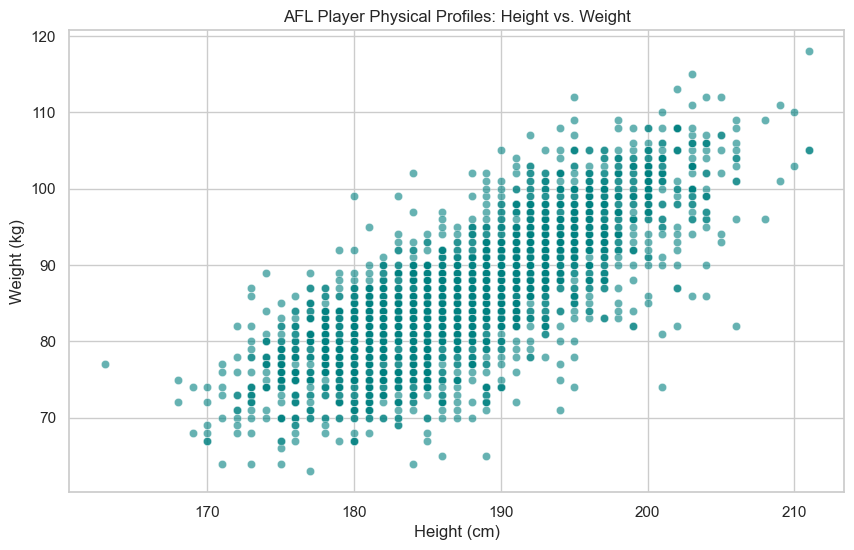

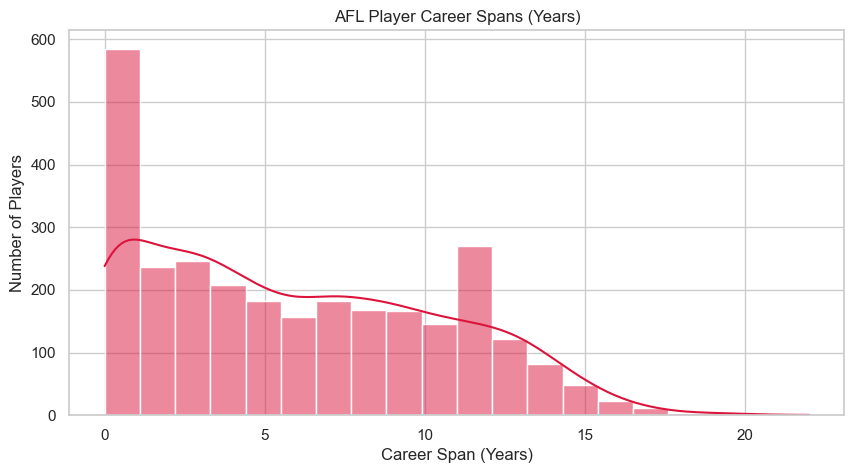

C:\Users\cadet\AppData\Local\Temp\ipykernel_11796\650748657.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fantasy_leaders, x='total_fantasy_points', y='player_name', palette='viridis')


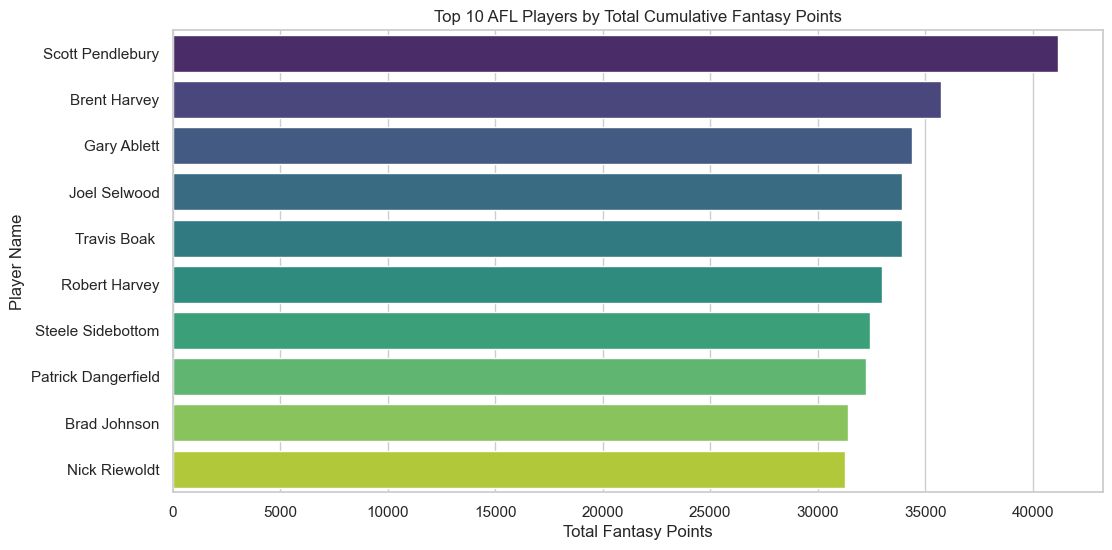

Top 5 Cumulative Fantasy Scorers:
 player_id      player_name  total_fantasy_points
     44673 Scott Pendlebury                 41196
     45576     Brent Harvey                 35753
     43262      Gary Ablett                 34388
     44892     Joel Selwood                 33929
     43406     Travis Boak                  33923


In [7]:
# 1. Height vs. Weight Analysis
plt.figure(figsize=(10, 6))
# Filter out rows with missing info or zero weight
df_valid_profiles = df_info[(df_info['height'] > 0) & (df_info['weight'] > 0)]
sns.scatterplot(data=df_valid_profiles, x='height', y='weight', alpha=0.6, color='teal')
plt.title('AFL Player Physical Profiles: Height vs. Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')

# Calculate correlation
correlation = df_valid_profiles['height'].corr(df_valid_profiles['weight'])
print(f"Correlation between height and weight: {correlation:.3f}")
plt.show()

# 2. Career Longevity (Active seasons in info)
df_info['debut_year'] = pd.to_datetime(df_info['debut_date'], errors='coerce').dt.year
df_info['last_year'] = pd.to_datetime(df_info['last_date'], errors='coerce').dt.year
df_info['career_span'] = df_info['last_year'] - df_info['debut_year']

plt.figure(figsize=(10, 5))
sns.histplot(df_info['career_span'].dropna(), bins=20, kde=True, color='crimson')
plt.title('AFL Player Career Spans (Years)')
plt.xlabel('Career Span (Years)')
plt.ylabel('Number of Players')
plt.show()

# 3. Top Career Fantasy Scorers in the dataset
# Sum fantasy points by player
fantasy_leaders = df_merged.groupby(['player_id', 'player_name'])['total_fantasy_points'].sum().reset_index()
fantasy_leaders = fantasy_leaders.sort_values(by='total_fantasy_points', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=fantasy_leaders, x='total_fantasy_points', y='player_name', palette='viridis')
plt.title('Top 10 AFL Players by Total Cumulative Fantasy Points')
plt.xlabel('Total Fantasy Points')
plt.ylabel('Player Name')
plt.show()

print("Top 5 Cumulative Fantasy Scorers:")
print(fantasy_leaders.head(5).to_string(index=False))
